# Clock jitter, TIE, and phase-noise analysis

This notebook analyzes a vector of rising-edge 0 V crossing times. The input is assumed to contain one timestamp per clock cycle, in chronological order. The example CSV is headerless and stores time in seconds.

The workflow compares two ideal-clock references: a least-squares fitted clock and a clock anchored to the first crossing with the average measured period. It calculates cumulative TIE, centered and raw RMS jitter, histograms, TIE time histories, single-sideband phase noise, and RMS jitter recovered by integrating each phase-noise spectrum.

## 1. Imports and settings

Change `INPUT_CSV` for another crossing-time vector. Set `INPUT_TIME_SCALE` to convert the file values to seconds, for example `1e-12` when the input is in picoseconds. Leave the integration limits as `None` to use every measurable non-DC offset.

In [121]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

INPUT_CSV = Path("Clock_27MHz_LMK1C1104_full_TIE_min.csv")
INPUT_TIME_SCALE = 1.0
INTEGRATION_MIN_HZ = None
INTEGRATION_MAX_HZ = None

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

## 2. Load and validate the crossing times

The input must be a finite, strictly increasing, one-dimensional vector. Multiplying by `INPUT_TIME_SCALE` converts it to seconds.

In [122]:
crossing_times_s = np.loadtxt(INPUT_CSV, delimiter=",", dtype=float).reshape(-1)
crossing_times_s *= INPUT_TIME_SCALE

if crossing_times_s.size < 4:
    raise ValueError("At least four crossing times are required.")
if not np.all(np.isfinite(crossing_times_s)):
    raise ValueError("The crossing-time vector contains NaN or infinite values.")
if not np.all(np.diff(crossing_times_s) > 0):
    raise ValueError("Crossing times must be strictly increasing.")

print(f"Input file: {INPUT_CSV}")
print(f"Crossing times: {crossing_times_s.size:,}")
print(f"Record span: {(crossing_times_s[-1] - crossing_times_s[0]) * 1e3:.6f} ms")

Input file: Clock_27MHz_LMK1C1104_full_TIE_min.csv
Crossing times: 8,910
Record span: 0.329963 ms


## 3. Build two ideal-clock references and calculate TIE

For edge index $n$, both methods construct an ideal clock of the form

$$t_{ideal}[n] = t_0 + nT_0,$$

then calculate

$$x[n] = t_{measured}[n] - t_{ideal}[n].$$

**Least-squares fitted clock:** `polyfit` selects $t_0$ and $T_0$ using every crossing to minimize the sum of squared TIE values. This removes the best-fit timestamp offset and constant frequency error.

**First crossing + average period:** $t_0=t_{measured}[0]$ and $T_0=\operatorname{mean}(t[n+1]-t[n])$. This anchors the first ideal edge to the first measurement. Because the average period telescopes to $(t[N-1]-t[0])/(N-1)$, the final TIE is also zero.

TIE is cumulative under either reference. If $e_T[k]=(t[k+1]-t[k])-T_0$ is period error, then

$$x[n]=x[0]+\sum_{k=0}^{n-1}e_T[k].$$

The code below verifies this equivalence numerically.

In [123]:
edge_index = np.arange(crossing_times_s.size, dtype=float)

# Method 1: least-squares fitted clock.
fitted_period_s, fitted_intercept_s = np.polyfit(edge_index, crossing_times_s, 1)
fitted_frequency_hz = 1.0 / fitted_period_s
ideal_crossing_times_fitted_s = fitted_intercept_s + fitted_period_s * edge_index
tie_fitted_s = crossing_times_s - ideal_crossing_times_fitted_s

# Method 2: first crossing as the reference and average measured period.
average_period_s = np.mean(np.diff(crossing_times_s))
first_intercept_s = crossing_times_s[0]
average_frequency_hz = 1.0 / average_period_s
ideal_crossing_times_first_average_s = first_intercept_s + average_period_s * edge_index
tie_first_average_s = crossing_times_s - ideal_crossing_times_first_average_s

# TIE is equivalently the cumulative sum of period error plus the initial TIE.
period_error_fitted_s = np.diff(crossing_times_s) - fitted_period_s
period_error_first_average_s = np.diff(crossing_times_s) - average_period_s
tie_fitted_cumulative_s = np.concatenate(([tie_fitted_s[0]], tie_fitted_s[0] + np.cumsum(period_error_fitted_s)))
tie_first_average_cumulative_s = np.concatenate(([tie_first_average_s[0]], tie_first_average_s[0] + np.cumsum(period_error_first_average_s)))

# Backward-compatible aliases for the fitted-clock baseline.
clock_frequency_hz = fitted_frequency_hz
ideal_crossing_times_s = ideal_crossing_times_fitted_s
tie_s = tie_fitted_s

print("Reference comparison")
print(f"{'Method':<28} {'Period (ns)':>15} {'Frequency (MHz)':>18} {'Intercept (ns)':>17}")
print(f"{'Least-squares fit':<28} {fitted_period_s * 1e9:15.9f} {fitted_frequency_hz / 1e6:18.9f} {fitted_intercept_s * 1e9:17.9f}")
print(f"{'First crossing + average':<28} {average_period_s * 1e9:15.9f} {average_frequency_hz / 1e6:18.9f} {first_intercept_s * 1e9:17.9f}")
print()
print(f"Fitted cumulative-TIE error:       {np.max(np.abs(tie_fitted_s - tie_fitted_cumulative_s)) * 1e15:.6f} fs")
print(f"First/average cumulative-TIE error: {np.max(np.abs(tie_first_average_s - tie_first_average_cumulative_s)) * 1e15:.6f} fs")

Reference comparison
Method                           Period (ns)    Frequency (MHz)    Intercept (ns)
Least-squares fit               37.037036237       27.000000583       5.428487497
First crossing + average        37.037036744       27.000000214       5.426023895

Fitted cumulative-TIE error:       0.000037 fs
First/average cumulative-TIE error: 0.000032 fs


## 4. RMS jitter comparison

The primary jitter metric is the **centered TIE RMS**, which equals the population standard deviation. It removes the reference-dependent DC offset and is therefore consistent with phase-noise integration after the DC FFT bin is excluded.

The **uncentered RMS** $\sqrt{\operatorname{mean}(x^2)}$ is also shown. It includes both random variation and the TIE mean, so it can differ for the first-crossing reference. Period jitter is the first difference of TIE and is reported separately.

In [124]:
tie_fitted_centered_s = tie_fitted_s - np.mean(tie_fitted_s)
tie_first_average_centered_s = tie_first_average_s - np.mean(tie_first_average_s)

method_results = {
    "Least-squares fit": {
        "tie": tie_fitted_s,
        "tie_centered": tie_fitted_centered_s,
        "period_error": period_error_fitted_s,
    },
    "First crossing + average": {
        "tie": tie_first_average_s,
        "tie_centered": tie_first_average_centered_s,
        "period_error": period_error_first_average_s,
    },
}

print(f"{'Method':<28} {'Mean (ps)':>11} {'Centered RMS (ps)':>19} {'Raw RMS (ps)':>14} {'P-P (ps)':>11}")
for method_name, result in method_results.items():
    tie = result["tie"]
    result["mean_s"] = np.mean(tie)
    result["centered_rms_s"] = np.sqrt(np.mean(result["tie_centered"] ** 2))
    result["raw_rms_s"] = np.sqrt(np.mean(tie**2))
    result["peak_to_peak_s"] = np.ptp(tie)
    result["period_jitter_rms_s"] = np.sqrt(np.mean(result["period_error"] ** 2))
    print(
        f"{method_name:<28} {result['mean_s'] * 1e12:11.6f} "
        f"{result['centered_rms_s'] * 1e12:19.6f} {result['raw_rms_s'] * 1e12:14.6f} "
        f"{result['peak_to_peak_s'] * 1e12:11.6f}"
    )

print()
print(f"Period-jitter RMS (both methods): {method_results['Least-squares fit']['period_jitter_rms_s'] * 1e12:.6f} ps")

# Backward-compatible fitted-clock baseline values.
tie_rms_s = method_results["Least-squares fit"]["centered_rms_s"]
tie_peak_to_peak_s = method_results["Least-squares fit"]["peak_to_peak_s"]
period_jitter_s = period_error_fitted_s
period_jitter_rms_s = method_results["Least-squares fit"]["period_jitter_rms_s"]

Method                         Mean (ps)   Centered RMS (ps)   Raw RMS (ps)    P-P (ps)
Least-squares fit               0.000000            1.885577       1.885577   18.991636
First crossing + average        0.205296            2.292546       2.301719   18.231685

Period-jitter RMS (both methods): 2.219275 ps


## 5. TIE histogram

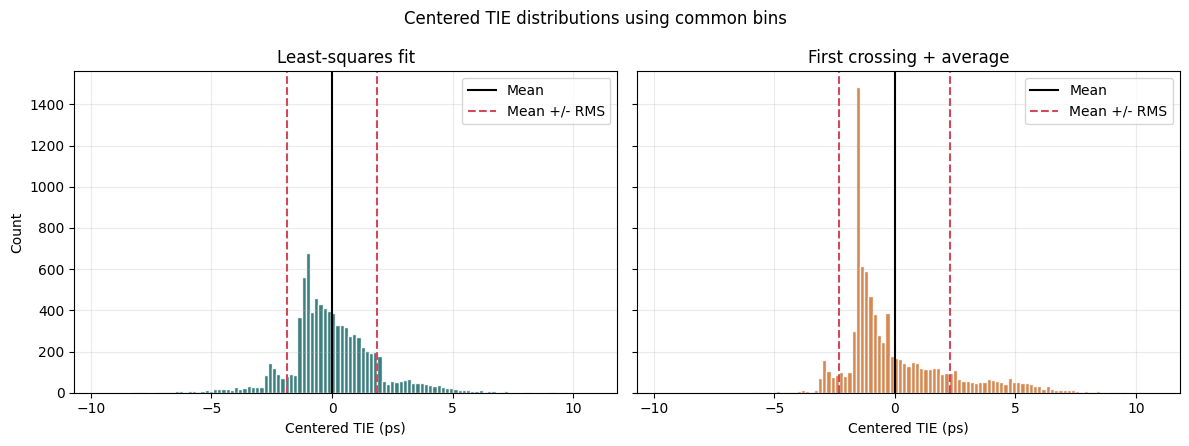

In [125]:
tie_fitted_centered_ps = tie_fitted_centered_s * 1e12
tie_first_average_centered_ps = tie_first_average_centered_s * 1e12
combined_centered_tie_ps = np.concatenate((tie_fitted_centered_ps, tie_first_average_centered_ps))
bin_edges = np.histogram_bin_edges(combined_centered_tie_ps, bins="fd")
if bin_edges.size < 2 or bin_edges.size > 201:
    bin_edges = np.histogram_bin_edges(
        combined_centered_tie_ps,
        bins=min(60, max(10, int(np.sqrt(combined_centered_tie_ps.size)))),
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
histogram_data = (
    (axes[0], "Least-squares fit", tie_fitted_centered_ps, "#287271"),
    (axes[1], "First crossing + average", tie_first_average_centered_ps, "#d17c3f"),
)
for axis, method_name, tie_centered_ps, color in histogram_data:
    rms_ps = method_results[method_name]["centered_rms_s"] * 1e12
    axis.hist(tie_centered_ps, bins=bin_edges, color=color, edgecolor="white", alpha=0.9)
    axis.axvline(0.0, color="black", linewidth=1.5, label="Mean")
    axis.axvline(-rms_ps, color="#d1495b", linestyle="--", label="Mean +/- RMS")
    axis.axvline(rms_ps, color="#d1495b", linestyle="--")
    axis.set_title(method_name)
    axis.set_xlabel("Centered TIE (ps)")
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel("Count")
fig.suptitle("Centered TIE distributions using common bins")
fig.tight_layout()
plt.show()

# Backward-compatible fitted-clock value.
tie_ps = tie_fitted_s * 1e12

## 6. TIE versus time

The raw TIE traces retain each method's reference-dependent offset and low-frequency shape. Their difference comes from the two ideal-clock lines, not from different measured crossings. The first/average trace is exactly zero at the first and final crossing; the least-squares trace minimizes residual energy over the full record.

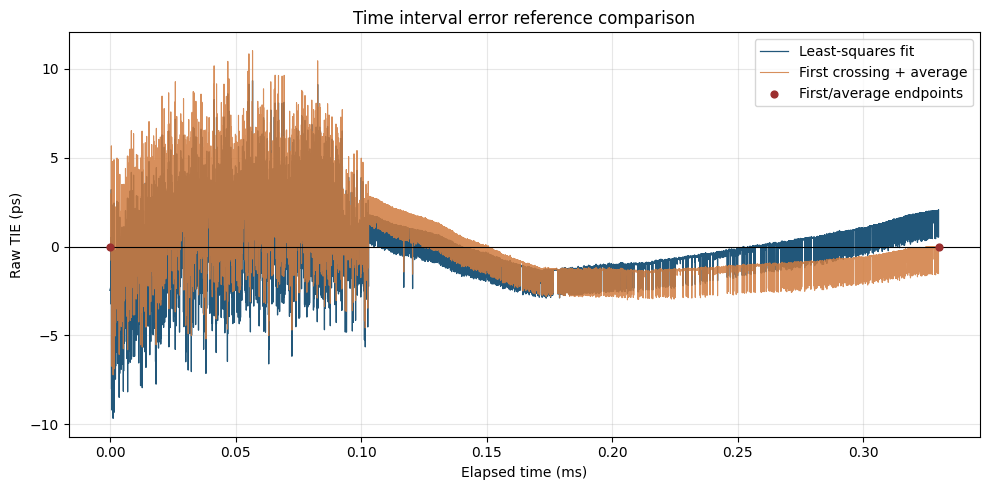

In [126]:
elapsed_time_ms = (crossing_times_s - crossing_times_s[0]) * 1e3
fig, ax = plt.subplots()
ax.plot(elapsed_time_ms, tie_fitted_s * 1e12, color="#22577a", linewidth=0.9, label="Least-squares fit")
ax.plot(
    elapsed_time_ms,
    tie_first_average_s * 1e12,
    color="#d17c3f",
    linewidth=0.8,
    alpha=0.85,
    label="First crossing + average",
)
ax.scatter(
    elapsed_time_ms[[0, -1]],
    tie_first_average_s[[0, -1]] * 1e12,
    color="#9c2f2f",
    s=24,
    zorder=3,
    label="First/average endpoints",
)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set(title="Time interval error reference comparison", xlabel="Elapsed time (ms)", ylabel="Raw TIE (ps)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Convert both TIE sequences to phase noise

Before spectral analysis, each TIE sequence is mean-centered because the DC timing offset is reference-dependent and is not phase noise at a nonzero offset frequency. Timing fluctuation becomes phase error through

$$\phi[n] = 2\pi f_0\left(x[n]-\overline{x}\right).$$

The notebook compares a rectangular window, $w[n]=1$, with a Hamming window. For either window, the one-sided PSD is normalized by its energy:

$$S_{\phi}(f_k)=\frac{|\operatorname{FFT}\{w[n]\phi[n]\}|^2}{f_s\sum_n w^2[n]}.$$

Equivalently, the Hamming amplitude needs the RMS correction

$$C_{RMS}=\frac{1}{\sqrt{U}},\qquad U=\frac{1}{N}\sum_n w^2[n].$$

This **power-gain** correction is the correct one for PSD and integrated noise. The coherent gain $\operatorname{mean}(w)$ is instead used for coherent tone amplitudes. The equivalent noise bandwidth is

$$\operatorname{ENBW}=f_s\frac{\sum_n w^2[n]}{\left(\sum_n w[n]\right)^2}.$$

From the one-sided phase PSD, single-sideband phase noise is $\mathcal{L}(f)=10\log_{10}(S_{\phi}(f)/2)$ dBc/Hz.

In [127]:
def calculate_phase_noise(tie_values_s, clock_frequency_hz, window_name="rectangular"):
    """Return a one-sided phase-error periodogram with window-power normalization."""
    tie_centered_s = np.asarray(tie_values_s, dtype=float) - np.mean(tie_values_s)
    phase_error_rad = 2.0 * np.pi * clock_frequency_hz * tie_centered_s
    sample_count = phase_error_rad.size
    sample_rate_hz = clock_frequency_hz

    if window_name == "rectangular":
        window = np.ones(sample_count)
    elif window_name == "hamming":
        window = np.hamming(sample_count)
    else:
        raise ValueError(f"Unsupported window: {window_name}")

    coherent_gain = np.mean(window)
    power_gain = np.mean(window**2)
    rms_correction = 1.0 / np.sqrt(power_gain)
    frequency_resolution_hz = sample_rate_hz / sample_count
    enbw_hz = sample_rate_hz * np.sum(window**2) / np.sum(window) ** 2
    enbw_bins = enbw_hz / frequency_resolution_hz

    windowed_tie_s = tie_centered_s * window
    windowed_total_rms_s = np.sqrt(np.sum(windowed_tie_s**2) / np.sum(window**2))
    windowed_dc_rms_s = abs(np.sum(windowed_tie_s)) / np.sqrt(sample_count * np.sum(window**2))
    windowed_non_dc_rms_s = np.sqrt(max(windowed_total_rms_s**2 - windowed_dc_rms_s**2, 0.0))

    phase_fft = np.fft.rfft(2.0 * np.pi * clock_frequency_hz * windowed_tie_s)
    offset_frequency_hz = np.fft.rfftfreq(sample_count, d=1.0 / sample_rate_hz)

    # Dividing by fs*sum(w^2) corrects the window's power loss and preserves rad^2/Hz.
    phase_psd_rad2_hz = np.abs(phase_fft) ** 2 / (sample_rate_hz * np.sum(window**2))
    if sample_count % 2 == 0:
        phase_psd_rad2_hz[1:-1] *= 2.0
    else:
        phase_psd_rad2_hz[1:] *= 2.0

    offset_frequency_hz = offset_frequency_hz[1:]
    phase_psd_rad2_hz = phase_psd_rad2_hz[1:]
    phase_noise_dbc_hz = 10.0 * np.log10(
        np.maximum(phase_psd_rad2_hz / 2.0, np.finfo(float).tiny)
    )
    return {
        "window_name": window_name,
        "offset_frequency_hz": offset_frequency_hz,
        "phase_psd_rad2_hz": phase_psd_rad2_hz,
        "phase_noise_dbc_hz": phase_noise_dbc_hz,
        "frequency_resolution_hz": frequency_resolution_hz,
        "coherent_gain": coherent_gain,
        "power_gain": power_gain,
        "rms_correction": rms_correction,
        "enbw_hz": enbw_hz,
        "enbw_bins": enbw_bins,
        "windowed_total_rms_s": windowed_total_rms_s,
        "windowed_dc_rms_s": windowed_dc_rms_s,
        "windowed_non_dc_rms_s": windowed_non_dc_rms_s,
    }

clock_references = {
    "Least-squares fit": (tie_fitted_s, fitted_frequency_hz),
    "First crossing + average": (tie_first_average_s, average_frequency_hz),
}
phase_results = {
    method_name: {
        window_name: calculate_phase_noise(tie_values_s, frequency_hz, window_name)
        for window_name in ("rectangular", "hamming")
    }
    for method_name, (tie_values_s, frequency_hz) in clock_references.items()
}

print(f"{'Window':<13} {'Coherent gain':>15} {'Power gain U':>15} {'RMS correction':>16} {'ENBW (bins)':>13}")
for window_name in ("rectangular", "hamming"):
    result = phase_results["Least-squares fit"][window_name]
    print(
        f"{window_name.title():<13} {result['coherent_gain']:15.9f} {result['power_gain']:15.9f} "
        f"{result['rms_correction']:16.9f} {result['enbw_bins']:13.6f}"
    )

print()
print(f"{'Method':<28} {'Resolution (Hz)':>17} {'Maximum offset (MHz)':>22}")
for method_name, windows in phase_results.items():
    result = windows["rectangular"]
    print(
        f"{method_name:<28} {result['frequency_resolution_hz']:17.3f} "
        f"{result['offset_frequency_hz'][-1] / 1e6:22.6f}"
    )

# Backward-compatible rectangular-window fitted-clock baseline values.
rectangular_fitted_result = phase_results["Least-squares fit"]["rectangular"]
offset_frequency_hz = rectangular_fitted_result["offset_frequency_hz"]
phase_psd_rad2_hz = rectangular_fitted_result["phase_psd_rad2_hz"]
phase_noise_dbc_hz = rectangular_fitted_result["phase_noise_dbc_hz"]
frequency_resolution_hz = rectangular_fitted_result["frequency_resolution_hz"]

Window          Coherent gain    Power gain U   RMS correction   ENBW (bins)
Rectangular       1.000000000     1.000000000      1.000000000      1.000000
Hamming           0.539948373     0.397356117      1.586390311      1.362936

Method                         Resolution (Hz)   Maximum offset (MHz)
Least-squares fit                     3030.303              13.500000
First crossing + average              3030.303              13.500000


## 8. Rectangular versus Hamming phase noise

The Hamming taper suppresses spectral leakage from the record boundaries, but broadens each spectral feature to an ENBW of about 1.363 FFT bins. The PSD energy normalization compensates its mean-square attenuation; no coherent-gain correction is applied to the noise spectrum.

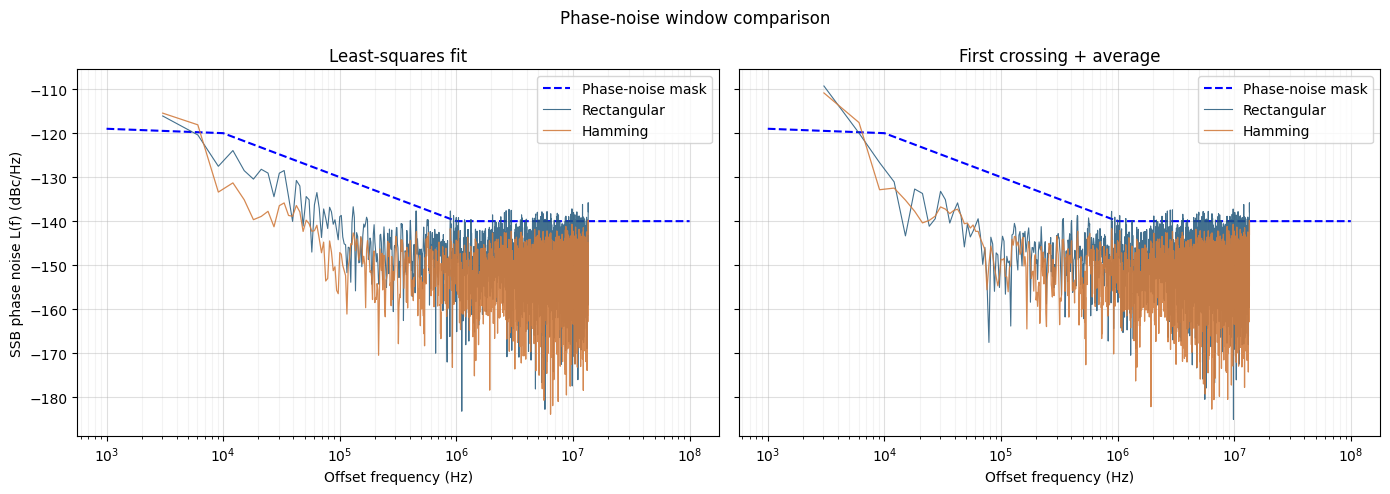

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
mask = [-119, -120, -130, -140, -140, -140]
mask_f = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8]
window_styles = {
    "rectangular": {"color": "#22577a", "linewidth": 0.8, "alpha": 0.85},
    "hamming": {"color": "#d17c3f", "linewidth": 0.9, "alpha": 0.9},
}

for axis, (method_name, windows) in zip(axes, phase_results.items()):
    axis.semilogx(mask_f, mask, linestyle="--", color="blue", label="Phase-noise mask")
    for window_name, result in windows.items():
        plot_mask = (result["offset_frequency_hz"] > 0) & np.isfinite(result["phase_noise_dbc_hz"])
        axis.semilogx(
            result["offset_frequency_hz"][plot_mask],
            result["phase_noise_dbc_hz"][plot_mask],
            label=window_name.title(),
            **window_styles[window_name],
        )
    axis.set_title(method_name)
    axis.set_xlabel("Offset frequency (Hz)")
    axis.grid(which="major", alpha=0.4)
    axis.grid(which="minor", alpha=0.15)
    axis.legend()

axes[0].set_ylabel("SSB phase noise L(f) (dBc/Hz)")
fig.suptitle("Phase-noise window comparison")
fig.tight_layout()
plt.show()

## 9. Recover RMS jitter and compare with the original time-domain RMS

Each plotted spectrum is converted back to phase PSD and integrated over the requested offset-frequency band:

$$S_{\phi}(f) = 2\cdot10^{\mathcal{L}(f)/10}, \qquad \sigma_t = \frac{\sqrt{\int S_{\phi}(f)\,df}}{2\pi f_0}.$$

For the rectangular window, full-band Parseval integration exactly reproduces the original centered RMS. For Hamming, division by $f_s\sum w^2$ removes the window's average power attenuation. This correction is unbiased for stationary random noise in expectation, but a single finite record need not match exactly because Hamming emphasizes its center and attenuates its endpoints. Excluding the DC bin can also remove a small window-induced weighted mean.

In [129]:
def integrate_phase_noise(phase_result, clock_frequency_hz, original_rms_s):
    frequencies_hz = phase_result["offset_frequency_hz"]
    integration_min_hz = frequencies_hz[0] if INTEGRATION_MIN_HZ is None else float(INTEGRATION_MIN_HZ)
    integration_max_hz = frequencies_hz[-1] if INTEGRATION_MAX_HZ is None else float(INTEGRATION_MAX_HZ)
    integration_mask = (frequencies_hz >= integration_min_hz) & (frequencies_hz <= integration_max_hz)
    if not np.any(integration_mask):
        raise ValueError("The selected integration band contains no FFT bins.")

    phase_psd_recovered = 2.0 * 10.0 ** (phase_result["phase_noise_dbc_hz"] / 10.0)
    phase_variance_rad2 = (
        np.sum(phase_psd_recovered[integration_mask]) * phase_result["frequency_resolution_hz"]
    )
    recovered_rms_jitter_s = np.sqrt(phase_variance_rad2) / (2.0 * np.pi * clock_frequency_hz)
    selected_frequencies_hz = frequencies_hz[integration_mask]
    full_non_dc_band = bool(np.all(integration_mask))
    windowed_parseval_target_s = (
        phase_result["windowed_non_dc_rms_s"] if full_non_dc_band else np.nan
    )
    fft_vs_target_percent_error = (
        100.0 * (recovered_rms_jitter_s - windowed_parseval_target_s) / windowed_parseval_target_s
        if full_non_dc_band and windowed_parseval_target_s > 0.0
        else np.nan
    )
    recovered_vs_original_percent = (
        100.0 * (recovered_rms_jitter_s - original_rms_s) / original_rms_s
        if original_rms_s > 0.0
        else np.nan
    )
    return {
        "minimum_hz": selected_frequencies_hz[0],
        "maximum_hz": selected_frequencies_hz[-1],
        "original_rms_s": original_rms_s,
        "windowed_parseval_target_s": windowed_parseval_target_s,
        "recovered_rms_s": recovered_rms_jitter_s,
        "fft_vs_target_percent_error": fft_vs_target_percent_error,
        "recovered_vs_original_percent": recovered_vs_original_percent,
    }

integration_results = {}
for method_name, windows in phase_results.items():
    clock_frequency_hz = clock_references[method_name][1]
    original_rms_s = method_results[method_name]["centered_rms_s"]
    integration_results[method_name] = {
        window_name: integrate_phase_noise(window_result, clock_frequency_hz, original_rms_s)
        for window_name, window_result in windows.items()
    }

print(
    f"{'Method':<28} {'Window':<13} {'Original (ps)':>14} {'Recovered (ps)':>15} "
    f"{'Parseval target (ps)':>21} {'FFT-target (%)':>16} {'Vs original (%)':>16}"
)
for method_name, windows in integration_results.items():
    for window_name, result in windows.items():
        print(
            f"{method_name:<28} {window_name.title():<13} {result['original_rms_s'] * 1e12:14.9f} "
            f"{result['recovered_rms_s'] * 1e12:15.9f} "
            f"{result['windowed_parseval_target_s'] * 1e12:21.9f} "
            f"{result['fft_vs_target_percent_error']:16.9f} "
            f"{result['recovered_vs_original_percent']:16.6f}"
        )

print()
for method_name, windows in integration_results.items():
    result = windows["hamming"]
    print(
        f"{method_name} Hamming band: {result['minimum_hz']:.3f} Hz to "
        f"{result['maximum_hz']:.3f} Hz"
    )

# Backward-compatible rectangular-window fitted-clock baseline values.
rectangular_fitted_integration = integration_results["Least-squares fit"]["rectangular"]
integration_min_hz = rectangular_fitted_integration["minimum_hz"]
integration_max_hz = rectangular_fitted_integration["maximum_hz"]
recovered_rms_jitter_s = rectangular_fitted_integration["recovered_rms_s"]
difference_percent = abs(rectangular_fitted_integration["recovered_vs_original_percent"])

Method                       Window         Original (ps)  Recovered (ps)  Parseval target (ps)   FFT-target (%)  Vs original (%)
Least-squares fit            Rectangular      1.885577130     1.885577130           1.885577130      0.000000000         0.000000
Least-squares fit            Hamming          1.885577130     1.405230124           1.405230124     -0.000000000       -25.474800
First crossing + average     Rectangular      2.292545521     2.292545521           2.292545521      0.000000000         0.000000
First crossing + average     Hamming          2.292545521     1.771160734           1.771160734     -0.000000000       -22.742614

Least-squares fit Hamming band: 3030.303 Hz to 13500000.292 Hz
First crossing + average Hamming band: 3030.303 Hz to 13500000.107 Hz


## 10. Interpretation

- Both definitions produce cumulative TIE: the difference between adjacent TIE samples is the period error relative to that method's reference period.
- Least squares uses every edge to minimize total squared TIE. For this record it gives 1.885577 ps centered RMS.
- First crossing + average period forces the first and final TIE values to zero and is more sensitive to endpoint noise and slow record shape. For this record it gives 2.292546 ps centered RMS.
- The first non-DC offset is $\Delta f=f_s/N$, so longer timestamp records resolve lower offset frequencies. The highest measurable offset is approximately $f_0/2$.
- Reference choice mainly affects DC and the lowest offset bins. The spectra generally converge at higher offsets because both use the same measured crossing fluctuations.
- Excluding the FFT DC bin means phase-noise integration recovers centered TIE RMS, not raw uncentered RMS. The raw TIE mean is reported separately.
- The Hamming PSD uses the power gain $U=0.397356$ and RMS correction $1/\sqrt{U}=1.586390$; coherent gain is not used for broadband-noise integration.
- Full-band rectangular integration reproduces the original RMS exactly. Full-band Hamming integration also matches its independent window-weighted Parseval target exactly, confirming the FFT scaling.
- The Hamming results are 1.405230 ps and 1.771161 ps, respectively 25.47% and 22.74% below the original unwindowed RMS values. Hamming emphasizes the center of this finite record, where the timing-error energy is lower, so power normalization cannot force equality with the unwindowed record.
- Hamming reduces leakage from abrupt record boundaries but broadens spectral features to an ENBW of 1.362936 bins. For accurate spur amplitudes, use the coherent gain and consider whether each spur is resolved.
- When integration limits are specified, the recovered result is band-limited RMS jitter and is not expected to equal either full-band time-domain value.